<h1>Modelling and Pricing of convertible bound </h1>

<p>Membres du groupe :</p>
<ul>
    <li><strong>KOUAME </strong> CHRIST ANGE DYLAN</li>
    <li><strong>OUATTARA </strong> ABOUBAKAR</li>
    <li><strong>OUATTARA </strong> SOULEYMANE</li>
</ul>


<p> <strong> Note : Dans tout le script , la seed a été fixée à 123 </strong> </p>


# Partie I : Création des fonctions

In [3]:
import numpy as np


#I) FONCTION POUR SIMULER S_t SELON EULER-MARUYAMA

def simulate_GBM_euler(S0, r, sigma, T, N, n_sim, return_paths=False, seed=123):
    np.random.seed(seed)
    dt = T / N

    if return_paths:
        paths = np.zeros((n_sim, N + 1))
        paths[:, 0] = S0
        S = paths[:, 0].copy()
    else:
        S = np.full(n_sim, S0, dtype=float)

    Z = np.random.normal(0, 1, size=(n_sim, N))

    for i in range(N):
        S += r * S * dt + sigma * S * np.sqrt(dt) * Z[:, i]
        if return_paths:
            paths[:, i + 1] = S

    return paths if return_paths else S

#III) FONCTION POUR FAIRE LA REGRESSION SUR (1,X,X^2) DE LA METHODE LSM

def quadratic_regression_predict(X, Y):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    A = np.column_stack((np.ones_like(X), X, X**2))
    coeffs, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
    Y_pred = A @ coeffs

    return coeffs, Y_pred


#III) FONCTION POUR CALCULER P*

def LSM_conversion_and_default(lambda_default, Cr, N_nominal, r, sigma, T, D, n_sim, S0, seed=123):
    dt = T / (D - 1)

    # 1) simulation sous-jacent
    S_paths = simulate_GBM_euler(
        S0=S0,
        r=r,
        sigma=sigma,
        T=T,
        N=D - 1,
        n_sim=n_sim,
        return_paths=True,
        seed=seed
    )

    X = Cr * S_paths   # valeur de conversion immédiate

    # 2) initialisation à maturité
    # payoff terminal = max(conversion, nominal)
    cashflow = np.maximum(X[:, -1], N_nominal)
    exercise_idx = np.full(n_sim, D - 1, dtype=int)

    # 3) backward induction
    for t in range(D - 2, -1, -1):
        # valeur de conversion immédiate
        immediate_ex = X[:, t]

        # valeur de continuation = payoff futur actualisé jusqu'à t
        continuation = cashflow * np.exp(-r * dt * (exercise_idx - t))

        # régression sur toutes les trajectoires encore vivantes
        _, continuation_pred = quadratic_regression_predict(immediate_ex, continuation)

        # règle d'exercice
        exercise_now = immediate_ex >= continuation_pred

        # si on exerce à t, on remplace la décision future
        cashflow[exercise_now] = immediate_ex[exercise_now]
        exercise_idx[exercise_now] = t

    # 4) reconstruction de V sous la forme que tu voulais
    V = np.zeros((n_sim, D))
    for i in range(n_sim):
        V[i, exercise_idx[i]] = cashflow[i]

    # 5) tau_c
    tau_c = exercise_idx * dt

    # 6) défaut
    rng = np.random.default_rng(seed + 1)
    tau_default = rng.exponential(scale=1.0 / lambda_default, size=n_sim)

    indicators = (tau_default < tau_c).astype(int)
    p_star_hat = indicators.mean()

    return V, tau_c, tau_default, p_star_hat, indicators, X


#IV) FONCTION POUR CALCULER LE SPREAD DU CDS SUR MESURE ( où p_star s'obtient par appel de la fonction precedente)

def cds_convertible_spread(R, lambda_default, p_star):
    """
    Calcule le spread du CDS sur obligation convertible.

    Formule :
        spread = lambda_default * (1 - R) * p_star

    Paramètres
    ----------
    R : float
        Taux de recovery, entre 0 et 1
    lambda_default : float
        Intensité de défaut
    p_star : float
        Probabilité de défaut avant conversion

    Retour
    ------
    spread : float
        Spread en valeur décimale
        (ex : 0.012 = 120 bps)
    """
    if not (0 <= R <= 1):
        raise ValueError("R doit être compris entre 0 et 1.")
    if lambda_default < 0:
        raise ValueError("lambda_default doit être positif.")
    if not (0 <= p_star <= 1):
        raise ValueError("p_star doit être compris entre 0 et 1.")

    spread = lambda_default * (1 - R) * p_star
    return spread

# Partie II : Aplication numérique et test de convergence vers p*

In [4]:
S0 = 89.23        # cours initial de l'action
r = 0.0213          # taux sans risque 3%
sigma = 0.25       # volatilité 30%
T = 5.0            # maturité 5 ans
D = int(T*365)+1           # 60 dates de discrétisation
n_sim = 100000      # 2000 simulations Monte Carlo
lambda_default = 0.0069 # intensité de défaut 4%
R = 0.40           # recovery 40%
N_nominal = 100.0  # nominal
Cp = 1.25 * S0    # prix de conversion stylisé
Cr = N_nominal / Cp

In [5]:
V, tau_c, tau_default, p_star_hat, indicators,X = LSM_conversion_and_default(
    lambda_default=lambda_default,
    Cr=Cr,
    N_nominal=N_nominal,
    r=r,
    sigma=sigma,
    T=T,
    D=D,
    n_sim=n_sim,
    S0=S0,
    seed=123
)

print("Cr =", Cr)
print("p* estimé =", p_star_hat)
print("Premières dates de conversion :", tau_c[:10])
print("Premières dates de défaut :", tau_default[:10])

Cr = 0.8965594530987335
p* estimé = 0.02866
Premières dates de conversion : [5.         1.33972603 1.24383562 5.         5.         4.66027397
 3.28767123 2.14520548 4.16712329 5.        ]
Premières dates de défaut : [156.35982271 177.68171688 328.81509013  75.82100562  55.42042814
 394.02504692 159.04878064  31.70949917 245.49873343  55.05161279]


In [6]:
R = 0.40
p_star = p_star_hat

spread = cds_convertible_spread(R, lambda_default, p_star)

print("Spread =", spread)
print("Spread en bps =", 10000 * spread)

Spread = 0.00011865239999999999
Spread en bps = 1.186524


In [79]:
import numpy as np
import time
import matplotlib.pyplot as plt


def monte_carlo_convergence_pstar(
    lambda_default,
    Cr,
    N_nominal,
    r,
    sigma,
    T,
    D,
    S0,
    sim_list=None,
    seed=123,
    plot=True
):
    """
    Étude de convergence Monte Carlo de p* = P(tau_default < tau_c)
    en fonction du nombre de simulations.

    Paramètres
    ----------
    lambda_default : float
        Intensité de défaut
    Cr : float
        Ratio de conversion
    N_nominal : float
        Nominal
    r : float
        Taux sans risque
    sigma : float
        Volatilité
    T : float
        Maturité
    D : int
        Nombre de dates de discrétisation
    S0 : float
        Valeur initiale du sous-jacent
    sim_list : list[int], optional
        Liste des tailles Monte Carlo à tester
    seed : int, optional
        Graine aléatoire de base
    plot : bool, optional
        Si True, affiche les graphes

    Retour
    ------
    results : dict
        Dictionnaire contenant :
        - "n_sim"
        - "p_star"
        - "times"
    """
    if sim_list is None:
        sim_list = [10_000, 50_000, 100_000, 500_000, 1_000_000]

    n_values = []
    pstar_values = []
    time_values = []

    for i, n_sim in enumerate(sim_list):
        start = time.time()

        V, tau_c, tau_default, p_star_hat, indicators, X = LSM_conversion_and_default(
            lambda_default=lambda_default,
            Cr=Cr,
            N_nominal=N_nominal,
            r=r,
            sigma=sigma,
            T=T,
            D=D,
            n_sim=n_sim,
            S0=S0,
            seed=seed + i
        )

        elapsed = time.time() - start

        n_values.append(n_sim)
        pstar_values.append(p_star_hat)
        time_values.append(elapsed)

        print(f"n_sim = {n_sim:>9,d} | p* = {p_star_hat:.6f} | temps = {elapsed:.2f} s")

    results = {
        "n_sim": np.array(n_values),
        "p_star": np.array(pstar_values),
        "times": np.array(time_values)
    }

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(results["n_sim"], results["p_star"], marker="o")
        plt.xscale("log")
        plt.xlabel("Nombre de simulations")
        plt.ylabel("Estimation de p*")
        plt.title("Convergence Monte Carlo de p*")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(results["n_sim"], results["times"], marker="o")
        plt.xscale("log")
        plt.xlabel("Nombre de simulations")
        plt.ylabel("Temps de calcul (secondes)")
        plt.title("Temps de calcul en fonction du nombre de simulations")
        plt.grid(True)
        plt.show()

    return results

n_sim =    10,000 | p* = 0.165400 | temps = 14.89 s
n_sim =    50,000 | p* = 0.156720 | temps = 69.45 s
n_sim =   100,000 | p* = 0.155030 | temps = 174.83 s
n_sim =   500,000 | p* = 0.156554 | temps = 598.33 s


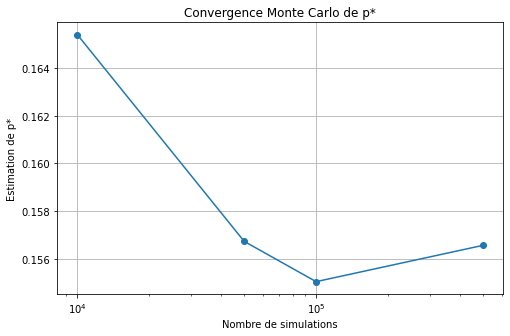

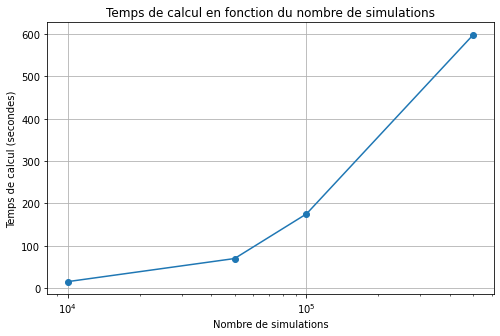

In [83]:
results = monte_carlo_convergence_pstar(
    lambda_default=lambda_default,
    Cr=Cr,
    N_nominal=N_nominal,
    r=r,
    sigma=sigma,
    T=T,
    D=D,
    S0=S0,
    sim_list=[10_000, 50_000, 100_000, 500_000],
    seed=123,
    plot=True
)

# Partie III : Analyse des sensibilités du spread